# **Notebook 2 - Customer Segmentation** 

Afonso Fernandes 20241710, Lourenço Lima 20241711, Lucas Casimiro 20241796



**IMPORTANT NOTE: after the association rules were used, we found the vegan cluster was contaminated with non-vegans. To fix this, we separated the cluster here based on the column `dietary_preference`, and re-ran the code to find the other clusters. We already know there are at least 6 more profiles to find.**

## Imports

In [1]:
import os
import sys
import warnings
from pathlib import Path

def _find_project_root(start, marker="requirements.txt"):
    path = Path(start).resolve()
    for candidate in [path] + list(path.parents):
        if (candidate / marker).exists():
            return str(candidate)
    raise RuntimeError(f"Could not find project root (marker={marker!r}, searched from {start})")

PROJECT_ROOT = _find_project_root(os.path.abspath("."))
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from functions.preprocessing import scale_features, FEATURE_COLS
from functions.clustering import *

import warnings
warnings.filterwarnings('ignore', category = FutureWarning)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## **1. Scaling**

Before proceeding, we will save 3 scaled datasets using 3 different scalers, to see which one gives the better results.

In [3]:
clean_data = pd.read_csv('data/ci_clustering.csv')

# Separating the vegan cluster, as mentioned in the beginning of the notebook
vegans = clean_data[clean_data['dietary_preference'] == 'vegetarian'].copy()
clean_data = clean_data[clean_data['dietary_preference'] != 'vegetarian'].copy().reset_index(drop=True)

display(clean_data)
display(vegans)

,customer_id,customer_name,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood,dietary_preference
0,3,Bsc. Crystal Kitchens,female,1.0,1.0,1.0,3.0,11731.0,4553.0,12.0,...,0.244917,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.013771,0.020656,omnivore
1,5,Msc. Antonio Campbell,male,0.0,0.0,0.0,2.0,12407.0,0.0,11.0,...,0.000000,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.006496,0.014277,omnivore
2,7,John Kelling,male,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,...,0.073903,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.110754,0.012306,omnivore
3,8,Arthur Dematteo,male,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,...,0.420243,0.014730,0.022948,0.027833,0.041400,0.039346,0.011513,0.048765,0.017095,omnivore
4,10,Phd. Franklin Alba,male,2.0,1.0,0.0,1.0,22240.0,0.0,9.0,...,0.000000,0.042292,0.017721,0.064888,0.046014,0.056752,0.029183,0.006686,0.003920,omnivore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28096,39996,Joshua Howard,male,0.0,0.0,2.0,1.0,475.0,13488.0,12.0,...,0.677108,0.009538,0.028765,0.049900,0.051205,0.057932,0.003112,0.080221,0.018373,omnivore
28097,39997,Anthony Hines,male,1.0,0.0,1.0,1.0,8430.0,14408.0,21.0,...,0.488076,0.009858,0.016836,0.048001,0.044817,0.020393,0.007453,0.071308,0.007690,omnivore
28098,39998,Edna Hasselman,female,1.0,1.0,0.0,4.0,8029.0,1480.0,14.0,...,0.105017,0.113532,0.035053,0.008302,0.021784,0.000000,0.121975,0.006315,0.018307,omnivore
28099,39999,George Kramer,male,1.0,1.0,1.0,6.0,8364.0,3114.0,11.0,...,0.225881,0.043232,0.021979,0.047947,0.000000,0.008197,0.029740,0.000000,0.016321,omnivore


,customer_id,customer_name,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood,dietary_preference
1,4,Bsc. Glenda Bauman,female,1.0,0.0,0.0,2.0,13694.0,963.0,12.0,...,0.047596,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.016458,0.032867,vegetarian
5,9,Msc. Nadine Garcia,female,1.0,1.0,1.0,6.0,16530.0,1156.0,6.0,...,0.055037,0.081318,0.019330,0.017282,0.001285,0.003618,0.024424,0.010712,0.000000,vegetarian
9,14,Msc. Arron Burgener,male,1.0,0.0,1.0,3.0,7981.0,2151.0,12.0,...,0.147855,0.114036,0.054922,0.008592,0.010173,0.001650,0.095752,0.012235,0.006186,vegetarian
22,30,Phd. Melissa Earing,female,1.0,0.0,1.0,1.0,8793.0,3285.0,9.0,...,0.206357,0.139393,0.029964,0.017652,0.002638,0.000000,0.038507,0.010177,0.002952,vegetarian
32,41,Bsc. Marion Davis,female,1.0,1.0,1.0,6.0,1806.0,1248.0,17.0,...,0.184561,0.290299,0.058858,0.048063,0.008134,0.006951,0.087992,0.018634,0.029429,vegetarian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32525,39944,Lynda Parrish,female,1.0,1.0,0.0,4.0,8871.0,214.0,12.0,...,0.014162,0.141420,0.033088,0.004765,0.014559,0.000463,0.168156,0.007478,0.028853,vegetarian
32541,39965,Mattie Eastman,female,1.0,1.0,0.0,6.0,13673.0,1867.0,12.0,...,0.087410,0.103282,0.022660,0.000890,0.002669,0.000000,0.117609,0.011986,0.013343,vegetarian
32556,39982,Patricia Miller,female,1.0,1.0,0.0,3.0,13004.0,1771.0,16.0,...,0.095113,0.105800,0.027820,0.017401,0.002954,0.006122,0.031042,0.010043,0.005317,vegetarian
32562,39990,Trevor Mcdowell,male,1.0,1.0,0.0,1.0,15353.0,3157.0,12.0,...,0.141462,0.091679,0.016310,0.013532,0.002106,0.002016,0.031053,0.007797,0.006094,vegetarian


In [4]:
# Standard Scaler
clean_std = scale_features(clean_data.copy(), StandardScaler)

# Robust Scaler
clean_rb = scale_features(clean_data.copy(), RobustScaler)

# MinMax Scaler
clean_minmax = scale_features(clean_data.copy(), MinMaxScaler)

## **2. Clustering**

The cluster analysis in the notebook is separated by scalers, and in each section 2 algorithms will be tested: `K-means` and `Hierarchical (Ward linkage)`. 

For each scaler section, 3 tasks are developed:
 - **Mathematical Comparison**: silhouette scores (a common analysis between both models) is used as a comparison between algorithms and plotted for each amount of clusters.
 - **Visual Inspection**: an elbow method is plotted to decide an amount for k in K-means, and a dendrogram is plotted to decide the amount of clusters created by Hierarchical Ward algorithm.
 - **Cluster Analysis**: collect insights based on the clusters created from both algorithms (profiling).
  
We specifically use the *Ward* linkage for our hierarchical model because it minimizes within-cluster variance (the exact same mathematical objective as K-Means). Below is proof of this linkage method superiority.

**NOTE**: in most cases, just following mathematical and visual proof will end up in under segmentation. In some cases, the choice for number of clusters is higher than the logical choice, as better results were obtained (more profiles, and more precise personas, backed by the data). Often, there's clear possibility of clusters representing more than 1 profile.

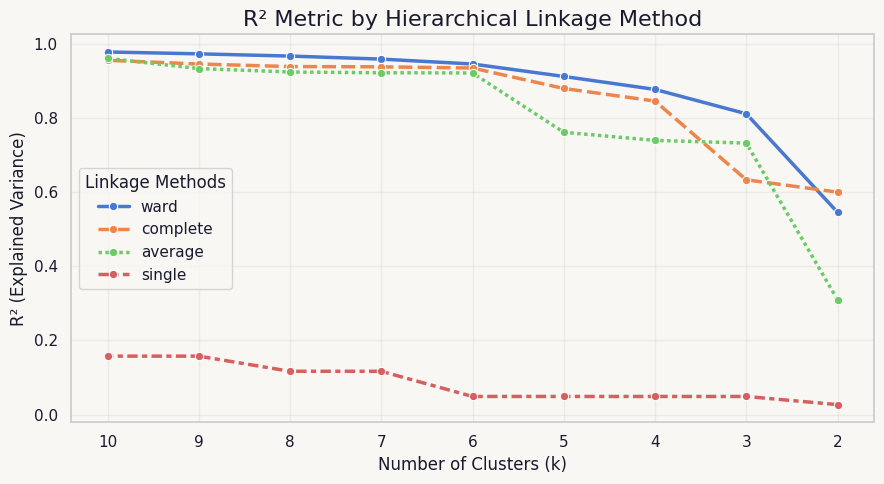

In [5]:
plot_r2_hc(clean_data, FEATURE_COLS)

## **Standard Scaler**

### Mathematical Comparison

In [6]:
results_std = compare_clustering_models(clean_std, FEATURE_COLS)
results_std

,model,k,silhouette
0,kmeans,10,0.145954
1,kmeans,9,0.139839
2,kmeans,8,0.136902
3,kmeans,7,0.136080
4,kmeans,6,0.127139
5,kmeans,3,0.126426
6,kmeans,4,0.125944
7,kmeans,5,0.117844
8,hierarchical_ward,9,0.112528
9,hierarchical_ward,10,0.109417


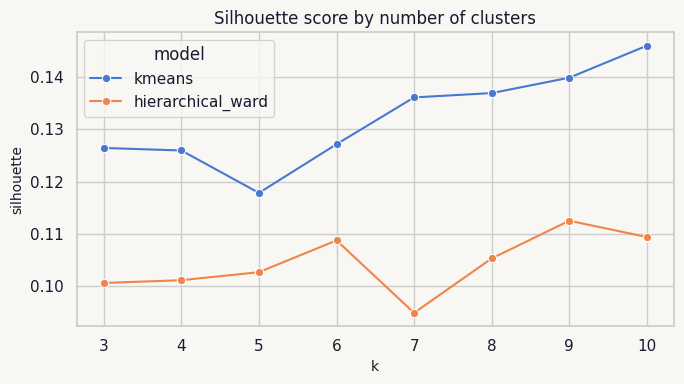

In [7]:
plot_metric_comparison(results_std)

### Visual Inspection

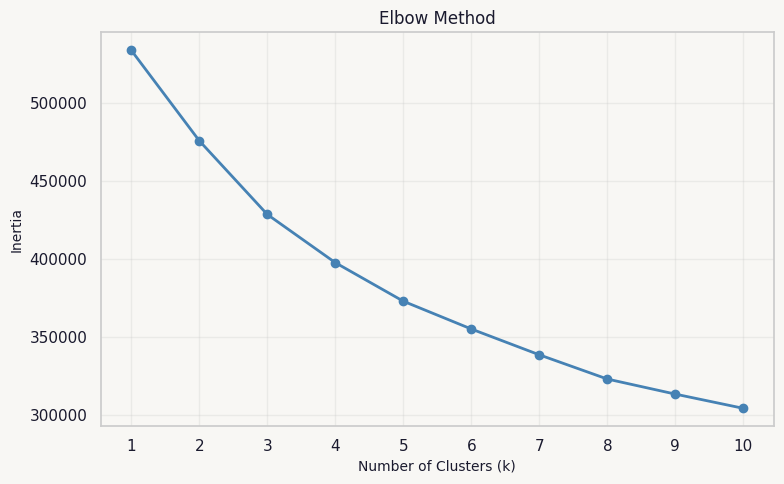

,k,inertia
0,1,533919.000000
1,2,475883.813644
2,3,428612.049576
3,4,397675.347375
4,5,372935.927942
5,6,355104.836728
6,7,338545.805744
7,8,323003.432112
8,9,313341.349182
9,10,304215.580576


In [8]:
compare_kmeans_inertia(clean_std, FEATURE_COLS)

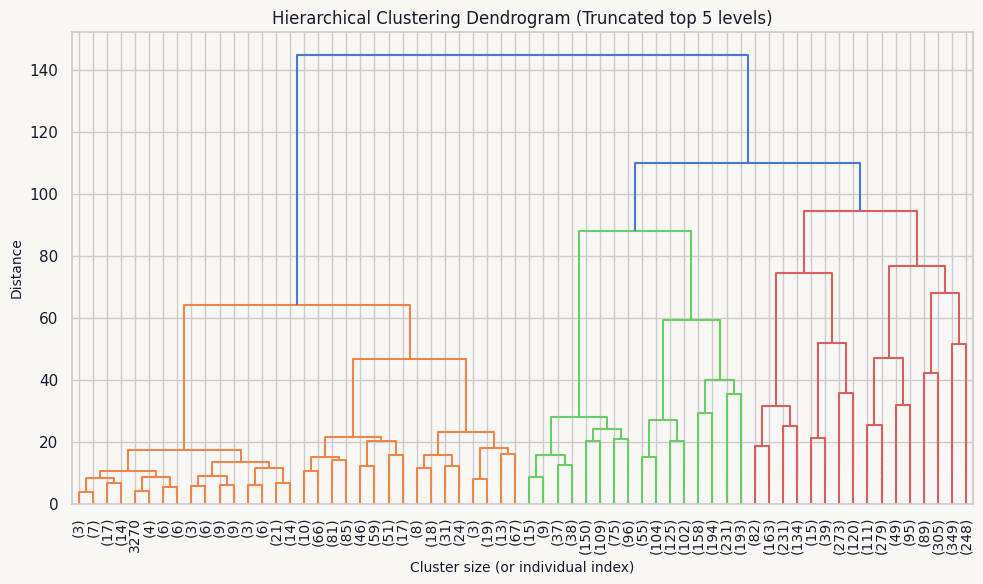

In [9]:
plot_dendrogram(clean_std, FEATURE_COLS)

### Cluster Analysis

In [32]:
optimal_k_kmeans_std = 10
optimal_k_ward_std = 9

In [33]:
kmeans_labels_std, kmeans_model_std = fit_final_kmeans(clean_std, FEATURE_COLS, n_clusters=optimal_k_kmeans_std)
final_std_k = add_clusters(clean_data, kmeans_labels_std, cluster_col='std_kmeans10')

calculate_group_means(final_std_k, cluster_col='std_kmeans10')

std_kmeans4,0,1,2,3,4,5,6,7,8,9
customer_id,19875.555766,19804.714722,19225.315179,20573.192031,19574.284842,20651.462222,20348.654804,20726.953516,19707.070457,19582.458873
kids_home,0.242654,0.901223,1.009077,1.833116,1.072906,0.111111,0.924081,0.563468,0.635569,3.478474
teens_home,0.306477,0.674741,0.866868,0.674069,0.951170,0.068148,0.846382,0.536055,0.841837,2.791040
number_complaints,1.071090,0.899106,0.562279,2.196277,1.115293,0.091852,0.932384,0.745828,0.330904,0.904095
distinct_stores_visited,1.445498,4.876999,3.577408,2.158393,3.720583,2.194074,3.571174,4.202026,1.781827,3.147707
lifetime_spend_groceries,8174.728594,18459.899577,12617.525466,11328.883410,42998.316378,10070.045926,4995.192171,11348.292908,19486.120262,24681.308715
lifetime_spend_electronics,10056.577567,2112.012700,937.153807,1106.275637,3816.806036,1637.285926,1751.241400,535.808999,1167.319971,4907.712986
typical_hour,17.437915,14.229304,11.184569,9.943828,13.405561,19.702222,12.391459,14.388558,8.420554,10.078404
lifetime_spend_vegetables,167.179463,454.095014,1321.337368,264.602221,391.181417,124.136296,455.184460,482.869190,689.781827,804.431222
lifetime_spend_nonalcohol_drinks,554.932070,486.994356,592.154816,245.221097,664.474398,283.238519,486.386714,171.091478,330.883382,820.483024


 - Cluster 0: Tech enthusiasts (gamers)
 - Cluster 1: Average customer
 - Cluster 2: Clean and healthy
 - Cluster 3: Karens
 - Cluster 4: Loyal older spenders
 - Cluster 5: Alcoholics (high alcohol share, late shopping hours, young)
 - Cluster 6: Early morning loyal customers
 - Cluster 7: Bargain hunters
 - Cluster 8: Early morning loyal customers?
 - Cluster 9: Big family (big spenders)


In [ ]:
ward_labels_std, ward_model_std = fit_final_hierarchical(clean_std, FEATURE_COLS, n_clusters=optimal_k_ward_std)
final_std_ward = add_clusters(clean_data, ward_labels_std, cluster_col='std_ward6')

calculate_group_means(final_std_ward, cluster_col='std_ward6')

std_ward6,0,1,2,3,4,5,6,7,8
customer_id,21034.032745,20286.753787,19184.560806,19406.968267,19799.368766,19824.678926,20207.008070,20533.633399,20376.903614
kids_home,0.854254,1.801160,0.914516,1.011798,3.252182,0.302685,0.586416,0.595191,0.048193
teens_home,0.730658,0.742830,0.744032,0.879577,2.629676,0.335377,0.848016,0.543808,0.041308
number_complaints,0.808026,2.364486,0.872419,0.606998,0.935786,1.023935,0.279758,0.758893,0.039587
distinct_stores_visited,4.042697,2.169836,4.232742,3.455248,3.166459,1.578225,1.587424,4.075758,2.058520
lifetime_spend_groceries,8211.959872,12849.007734,29446.526613,14507.315704,25029.852556,8623.678050,19773.080363,12071.177207,10202.509466
lifetime_spend_electronics,1702.451364,1249.691267,2650.983387,1150.092758,4878.102556,9487.773205,920.286819,568.324769,1604.950086
typical_hour,12.950562,10.445053,13.414677,11.593165,10.212282,17.061296,7.790518,14.191041,20.483649
lifetime_spend_vegetables,490.019583,266.679665,391.227419,1427.624491,794.227556,188.278167,597.529590,439.365942,104.263339
lifetime_spend_nonalcohol_drinks,471.977207,255.621656,537.932097,554.824247,811.010599,539.531232,306.827169,170.218709,277.752151


 - Cluster 0: Average customer
 - Cluster 1: Karens
 - Cluster 2: Loyal big spenders
 - Cluster 3: Clean and healthy
 - Cluster 4: Big families (big spenders)
 - Cluster 5: Tech enthusiasts
 - Cluster 6: Loyal core customers (early shoppers)
 - Cluster 7: Bargain hunters
 - Cluster 8: Young singles (high alcohol, low dependants)

## **Robust Scaler**

### Mathematical Comparison

In [53]:
results_rb = compare_clustering_models(clean_rb, FEATURE_COLS)
results_rb

,model,k,silhouette
0,kmeans,3,0.283084
1,hierarchical_ward,3,0.258771
2,kmeans,4,0.228509
3,hierarchical_ward,4,0.194232
4,kmeans,7,0.151837
5,kmeans,10,0.150812
6,kmeans,6,0.148881
7,kmeans,8,0.145302
8,hierarchical_ward,7,0.144138
9,kmeans,5,0.143462


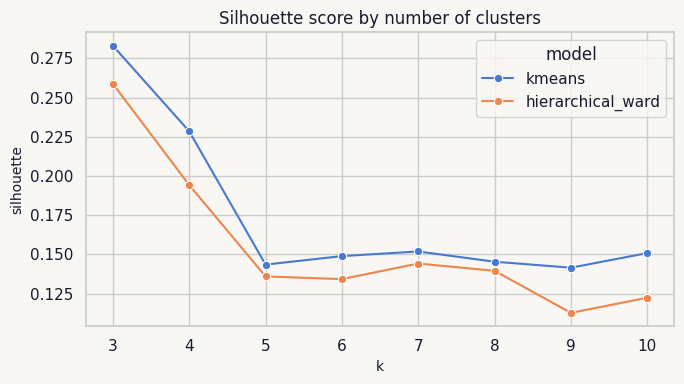

In [54]:
plot_metric_comparison(results_rb)

### Visual Inspection

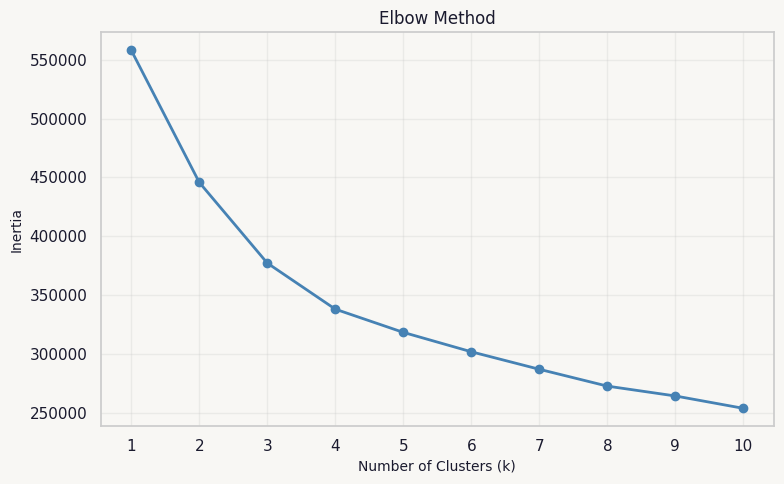

,k,inertia
0,1,558071.382993
1,2,445825.119379
2,3,377251.371179
3,4,338088.446533
4,5,318362.314645
5,6,301876.888258
6,7,286997.503514
7,8,272695.174616
8,9,264326.872058
9,10,253815.013319


In [55]:
compare_kmeans_inertia(clean_rb, FEATURE_COLS)

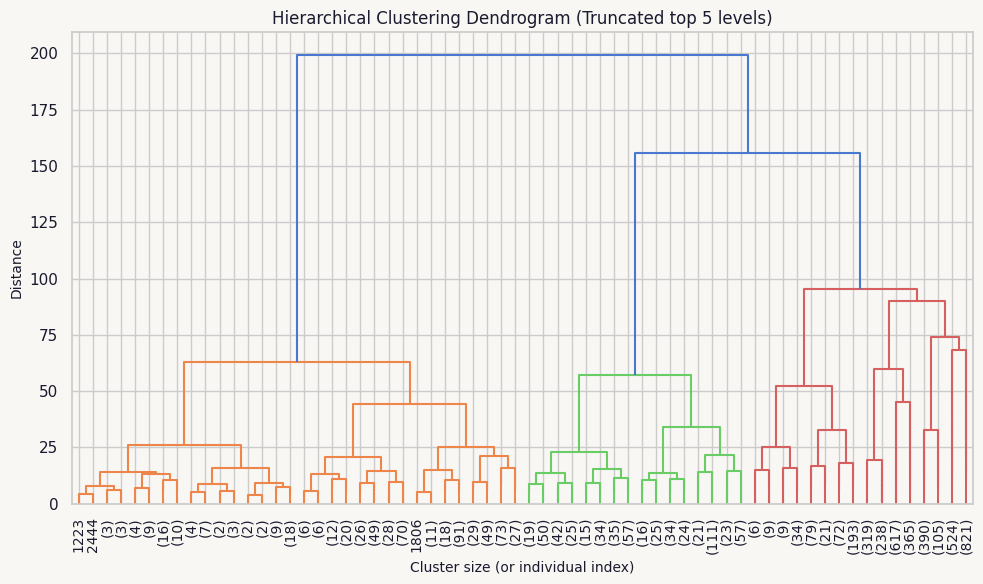

In [56]:
plot_dendrogram(clean_rb, FEATURE_COLS)

### Cluster Analysis

In [40]:
optimal_k_kmeans_rb = 8
optimal_k_ward_rb = 7

In [45]:
kmeans_labels_rb, kmeans_model_rb = fit_final_kmeans(clean_rb, FEATURE_COLS, n_clusters=optimal_k_kmeans_rb)
final_rb_kmeans = add_clusters(clean_data, kmeans_labels_rb, cluster_col='rb_kmeans8')

calculate_group_means(final_rb_kmeans, cluster_col='rb_kmeans8') 

rb_kmeans8,0,1,2,3,4,5,6,7
customer_id,20103.472479,19668.854991,19738.853975,19543.266732,20118.149679,20578.024150,19662.879007,20286.950461
kids_home,0.810767,0.238382,3.882845,1.024114,0.532155,0.364937,1.131740,1.809332
teens_home,0.738449,0.286575,3.051883,0.891732,0.527875,0.391771,1.028720,0.821141
number_complaints,0.858176,1.065404,0.908787,0.560531,0.530803,1.037567,0.927182,2.195853
distinct_stores_visited,3.787867,1.434596,3.222176,3.524114,3.316928,1.899821,3.807671,2.352823
lifetime_spend_groceries,5734.081961,8753.192341,25085.164017,12710.580709,15692.883771,7609.042039,34232.750232,12069.523618
lifetime_spend_electronics,1504.188027,11959.694923,4901.668201,956.396654,1148.092015,3978.954383,3300.110617,1250.905242
typical_hour,12.811973,17.410069,10.157741,11.153051,12.496903,16.403399,12.725032,10.518433
lifetime_spend_vegetables,473.699879,173.828744,807.563598,1340.600394,528.584863,226.707513,453.637762,294.025346
lifetime_spend_nonalcohol_drinks,414.848534,553.003873,811.569456,582.903051,297.833427,507.644007,626.229572,279.245104


 - Cluster 0: Bargain hunters
 - Cluster 1: Tech enthusiasts
 - Cluster 2: Big families (big spenders)
 - Cluster 3: Clean and healthy
 - Cluster 4: Average customer
 - Cluster 5: Gamers
 - Cluster 6: Loyal big spenders
 - Cluster 7: Karens

In [38]:
ward_labels_rb, ward_model_rb = fit_final_hierarchical(clean_rb, FEATURE_COLS, n_clusters=optimal_k_ward_rb)
final_rb_ward = add_clusters(clean_data, ward_labels_rb, cluster_col='rb_ward7')

calculate_group_means(final_rb_ward, cluster_col='rb_ward7')

rb_ward7,0,1,2,3,4,5,6
customer_id,20143.763209,19967.857407,19862.453631,20129.164164,19448.565702,19602.647275,20066.566886
kids_home,0.610645,0.259316,3.872703,1.019019,1.022272,1.118512,1.878673
teens_home,0.614837,0.315676,3.050744,0.886220,0.879176,0.968642,0.732112
number_complaints,0.578280,1.066215,0.926947,1.038372,0.515590,0.930580,2.270999
distinct_stores_visited,3.347534,1.499230,3.223097,3.726059,3.555122,3.734213,2.255099
lifetime_spend_groceries,16431.624781,8230.471204,25477.476815,8264.982983,13467.658129,33370.011678,13175.628413
lifetime_spend_electronics,1105.073699,9663.356637,4911.415136,1783.894895,867.616370,3881.482915,1106.135845
typical_hour,12.298694,17.222667,10.155731,12.967634,10.864143,13.033953,10.315589
lifetime_spend_vegetables,540.344317,179.981521,810.920385,525.480480,1287.104120,430.193772,275.271690
lifetime_spend_nonalcohol_drinks,295.593488,549.455805,812.237533,488.479146,604.044543,664.384083,245.127549


 - Cluster 0: Average customer
 - Cluster 1: Tech enthusiasts
 - Cluster 2: Big families (big spenders)
 - Cluster 3: Bargain hunters
 - Cluster 4: Clean and healthy
 - Cluster 5: Loyal big spenders
 - Cluster 6: Karens

## **MinMax Scaler**

### Mathematical Comparison

In [24]:
results_minmax = compare_clustering_models(clean_minmax, FEATURE_COLS)
results_minmax

,model,k,silhouette
0,kmeans,4,0.171685
1,kmeans,3,0.160689
2,kmeans,5,0.155357
3,kmeans,6,0.150522
4,kmeans,7,0.143405
5,hierarchical_ward,3,0.142909
6,hierarchical_ward,4,0.139393
7,kmeans,8,0.137333
8,kmeans,9,0.136411
9,kmeans,10,0.135764


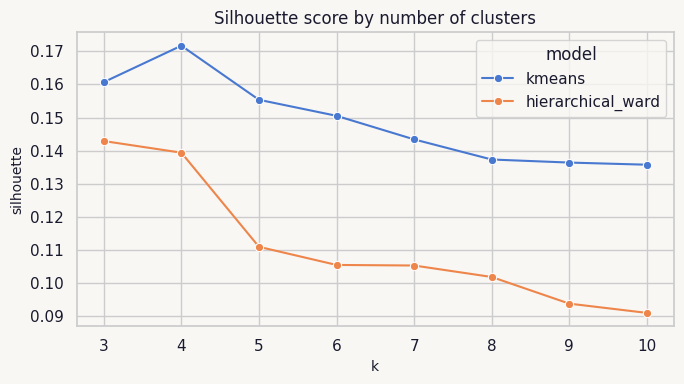

In [25]:
plot_metric_comparison(results_minmax)

### Visual Inspection

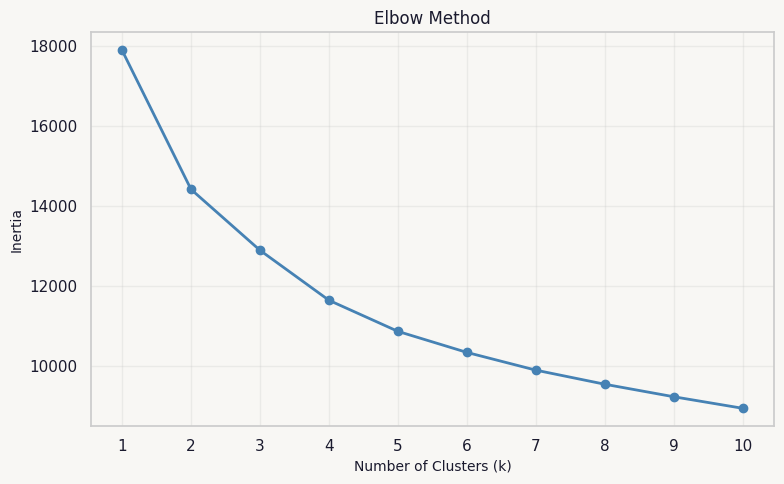

,k,inertia
0,1,17901.924653
1,2,14423.204421
2,3,12899.536959
3,4,11649.499050
4,5,10872.530798
5,6,10346.457761
6,7,9902.869482
7,8,9550.452738
8,9,9237.707381
9,10,8948.781928


In [26]:
compare_kmeans_inertia(clean_minmax, FEATURE_COLS)

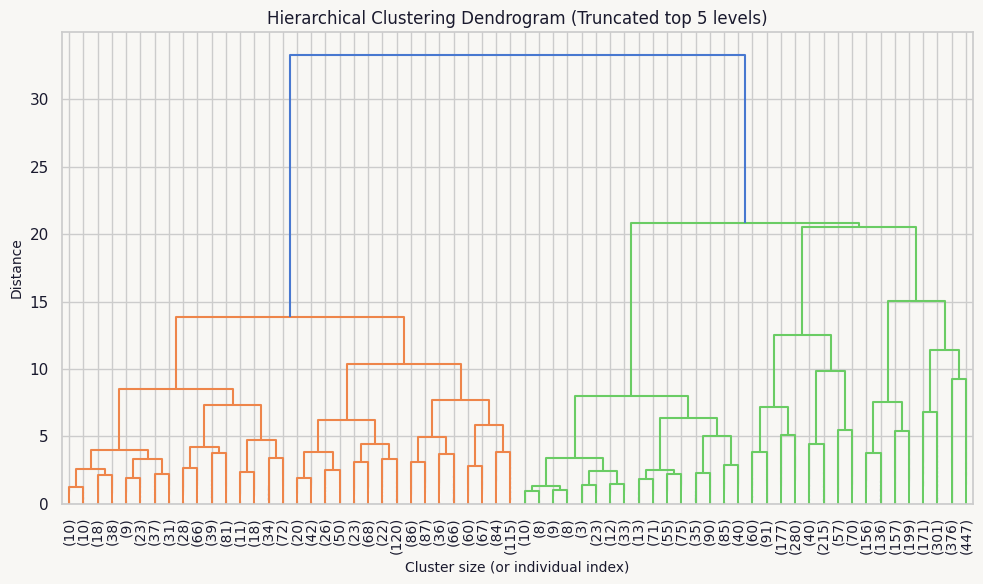

In [27]:
plot_dendrogram(clean_minmax, FEATURE_COLS)

### Cluster Analysis

In [42]:
optimal_k_kmeans_minmax = 6
optimal_k_ward_minmax = 4

In [43]:
kmeans_labels_minmax, kmeans_model_minmax = fit_final_kmeans(clean_minmax, FEATURE_COLS, n_clusters=optimal_k_kmeans_minmax)
final_minmax_kmeans = add_clusters(clean_data, kmeans_labels_minmax, cluster_col='minmax_kmeans6')

calculate_group_means(final_minmax_kmeans, cluster_col='minmax_kmeans6')

minmax_kmeans6,0,1,2,3,4,5
customer_id,23677.664639,23887.727078,9479.504422,21389.634026,11700.994504,24642.170279
kids_home,1.435932,0.878320,0.839406,0.327407,1.415388,1.366599
teens_home,0.930418,0.564482,0.664308,0.360777,1.260186,1.210354
number_complaints,1.115209,1.031919,0.938451,0.993435,0.725223,0.877748
distinct_stores_visited,2.707795,3.845116,4.193138,1.875547,3.007580,3.297053
lifetime_spend_groceries,16646.284601,14212.380463,21180.187124,9943.264770,20435.888384,21351.560424
lifetime_spend_electronics,2177.327947,1168.738003,2008.652989,8033.669858,2415.396816,2695.904881
typical_hour,9.729087,14.054627,15.923240,19.484956,9.828501,10.741775
lifetime_spend_vegetables,527.685741,389.063839,422.317297,226.354759,754.551260,632.794168
lifetime_spend_nonalcohol_drinks,420.504563,278.471080,440.489919,517.751094,550.071442,538.049431


 - Cluster 0: Young karens?
 - Cluster 1: Bargain hunters
 - Cluster 2: Loyal bargain hunters?
 - Cluster 3: Tech enthusiasts
 - Cluster 4: Loyal core spenders
 - Cluster 5: Big senior spenders (poorly defined)

In [44]:
ward_labels_minmax, ward_model_minmax = fit_final_hierarchical(clean_minmax, FEATURE_COLS, n_clusters=optimal_k_ward_minmax)
final_minmax_ward = add_clusters(clean_data, ward_labels_minmax, cluster_col='minmax_ward7')

calculate_group_means(final_minmax_ward, cluster_col='minmax_ward7')

minmax_ward7,0,1,2,3
customer_id,24601.550122,10976.452475,20055.739652,24683.989201
kids_home,1.516283,1.178071,0.192417,0.930742
teens_home,1.138856,1.038650,0.256872,0.675882
number_complaints,0.952901,0.798926,0.875513,1.127142
distinct_stores_visited,2.827835,3.384517,1.538073,3.946292
lifetime_spend_groceries,18146.101517,20537.886969,8473.920063,17441.300792
lifetime_spend_electronics,2753.912698,2220.382298,8477.289731,1466.630526
typical_hour,9.938687,11.997314,19.445814,13.794528
lifetime_spend_vegetables,597.513843,649.073097,149.801896,430.172642
lifetime_spend_nonalcohol_drinks,504.053145,498.653667,510.143760,340.730598


 - Cluster 0: Big families (badly defined)
 - Cluster 1: Loyal core spenders
 - Cluster 2: Tech enthusiasts
 - Cluster 3: Karens / Bargain hunters


# **3. Final Clustering Solution**

Recap of the results:
 - The Standard Scaler, interestingly, increased silhouette score with more clusters. The kmeans with 10 clusters showed some doubts, but we will map the hierarchical (ward linkage) with umap for comparison.
 - The Robust Scaler showed us 2 valid solutions, and we will map the kmeans result with 8 clusters with umap for comparison.
 - The MinMax Scaler yielded poor results, as even with fewer clusters, it was hard to define profiles. 

Before mapping our results, we will join the vegan cluster back 


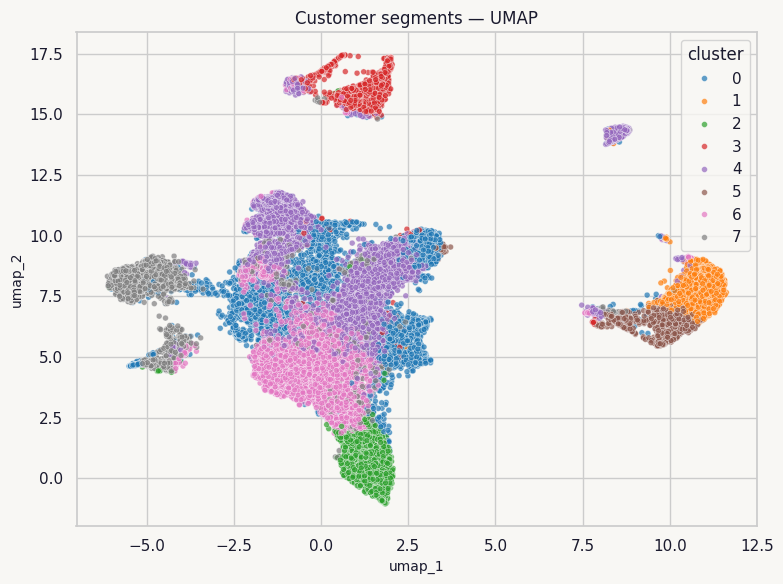

In [50]:
# Joining vegans back with standard scaler
vegans_scl_std = scale_features(vegans.copy(), StandardScaler)
combo_scl_std = pd.concat([vegans_scl_std, clean_rb], ignore_index=True)
vegans_labels = np.zeros(len(vegans), dtype=int)
combo_labels_std = np.concatenate([vegans_labels, kmeans_labels_rb])

plot_umap_cluster_map(combo_scl_std, FEATURE_COLS, combo_labels_std)

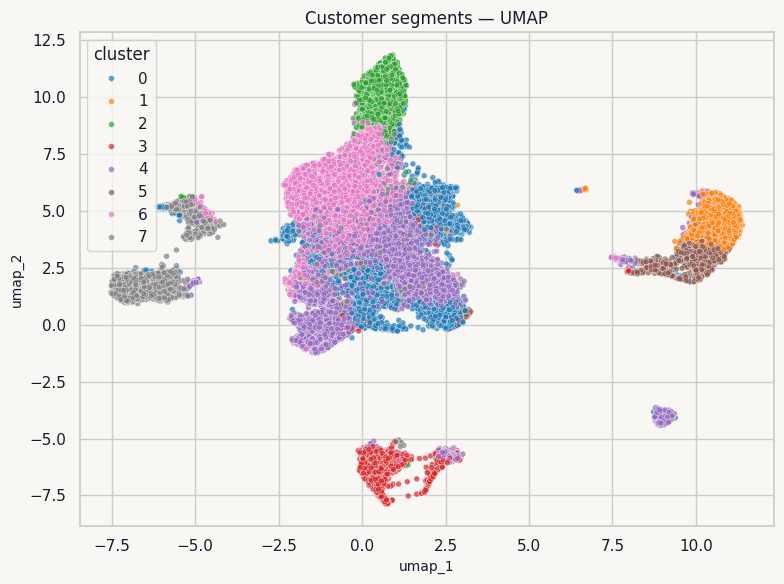

In [ ]:
# Scale vegans with RobustScaler
vegans_scaled = scale_features(vegans.copy(), RobustScaler)

# Combine vegans with clean_rb (scaled data)
combined_scaled = pd.concat([vegans_scaled, clean_rb], ignore_index=True)

# Create labels for vegans (all cluster 0) and shift other clusters by +1
vegan_labels = np.zeros(len(vegans), dtype=int)
shifted_kmeans_labels = kmeans_labels_rb + 1  # Shift clusters 0-7 to 1-8
combined_labels = np.concatenate([vegan_labels, shifted_kmeans_labels])

# Plot UMAP with combined data including vegans
plot_umap_cluster_map(combined_scaled, FEATURE_COLS, combined_labels)

In [46]:
calculate_group_means(final_rb_kmeans, cluster_col='rb_kmeans8')

rb_kmeans8,0,1,2,3,4,5,6,7
customer_id,20103.472479,19668.854991,19738.853975,19543.266732,20118.149679,20578.024150,19662.879007,20286.950461
kids_home,0.810767,0.238382,3.882845,1.024114,0.532155,0.364937,1.131740,1.809332
teens_home,0.738449,0.286575,3.051883,0.891732,0.527875,0.391771,1.028720,0.821141
number_complaints,0.858176,1.065404,0.908787,0.560531,0.530803,1.037567,0.927182,2.195853
distinct_stores_visited,3.787867,1.434596,3.222176,3.524114,3.316928,1.899821,3.807671,2.352823
lifetime_spend_groceries,5734.081961,8753.192341,25085.164017,12710.580709,15692.883771,7609.042039,34232.750232,12069.523618
lifetime_spend_electronics,1504.188027,11959.694923,4901.668201,956.396654,1148.092015,3978.954383,3300.110617,1250.905242
typical_hour,12.811973,17.410069,10.157741,11.153051,12.496903,16.403399,12.725032,10.518433
lifetime_spend_vegetables,473.699879,173.828744,807.563598,1340.600394,528.584863,226.707513,453.637762,294.025346
lifetime_spend_nonalcohol_drinks,414.848534,553.003873,811.569456,582.903051,297.833427,507.644007,626.229572,279.245104


## Clusters mapping

### Vegans
Higher share of spending on vegetables, very low meat and fish spending, moderate household size, and relatively low promotion usage. These customers appear to have healthier or more plant-based purchasing habits. They are not the highest spenders, but their category preferences are very clear.

### Loyal core spenders 
Largest cluster, high grocery spending, high total spend, high loyalty card ownership, long customer tenure and many distinct products purchased. This is the supermarket’s core customer base. They are loyal, regular, broad shoppers and represent a stable source of revenue.

### Big families
Highest number of dependants, highest total spend, highest number of distinct products purchased and strong grocery spending. These customers likely represent large households. Their purchases are broad and high-volume, making them highly valuable for family-oriented campaigns.

### Bargain hunters
Highest percentage of products bought on promotion, many stores visited, relatively low total spend and strong loyalty card ownership. These customers are very price-sensitive and actively react to promotions. They may compare options and visit different stores to maximize discounts.

### Gamers
High videogame spending share, high electronics spending share, later shopping hours and fewer dependants. This segment is more focused on entertainment and technology-related products, especially videogames.

### Karens 
Highest number of complaints, younger average age, high promotion usage, lower loyalty card ownership and fewer distinct products purchased. These customers seem more difficult to satisfy and are also sensitive to promotions. They may require targeted retention actions and better customer experience management.

### Tech enthusiasts
Highest electronics spending share, high total electronics spend, later shopping hours, fewer dependants and lower grocery dependency. This segment is strongly technology-oriented. They spend a large part of their budget on electronics and are suitable for campaigns around gadgets and tech bundles.

In [ ]:
# Mapping each cluster to its corresponding label
clusters_mapping = {
    0: 'Vegans',
    1: 'Bargain hunters',
    2: 'Tech enthusiasts',
    3: 'Big families (big spenders)',
    4: 'Clean and healthy',
    5: 'Average customer',
    6: 'Gamers',
    7: 'Loyal big spenders',
    8: 'Karens'}

In [29]:
# Creating new columns with corresponding cluster for each customer
clean_data['final_cluster_nr'] = final_rb_ward['rb_ward7']
clean_data['final_cluster_label'] = [clusters_mapping[i] for i in clean_data['final_cluster_nr']]


In [ ]:
#Checking the counts for each cluster
clean_data['final_cluster_label'].value_counts()

final_cluster_label
Loyal core spenders            11606
Vegans                          6636
Bargain hunters                 5662
Karens                          3123
Tech enthusiasts                2185
Big families (big spenders)     2131
Gamers                          1228
Name: count, dtype: int64

The umap definition definitely shows cluster relationships, despite some fragmentation, which could be justified from these points:
 - The joined clusters (1,2 and 3) have one thing in common: high loyalty card percentage, hence their overlap. 
 - Clusters 4 and 6 are both into technologies, just with slightly different personas (simply tech enthusiasts vs gamers).
 - Lastly, cluster 3 (bargain hunters) has points spread out over the map, as these exhibit some distinct behaviors between them, possibly shared with other clusters, but come together with a very high percentage of products bought in promotions (0.55).

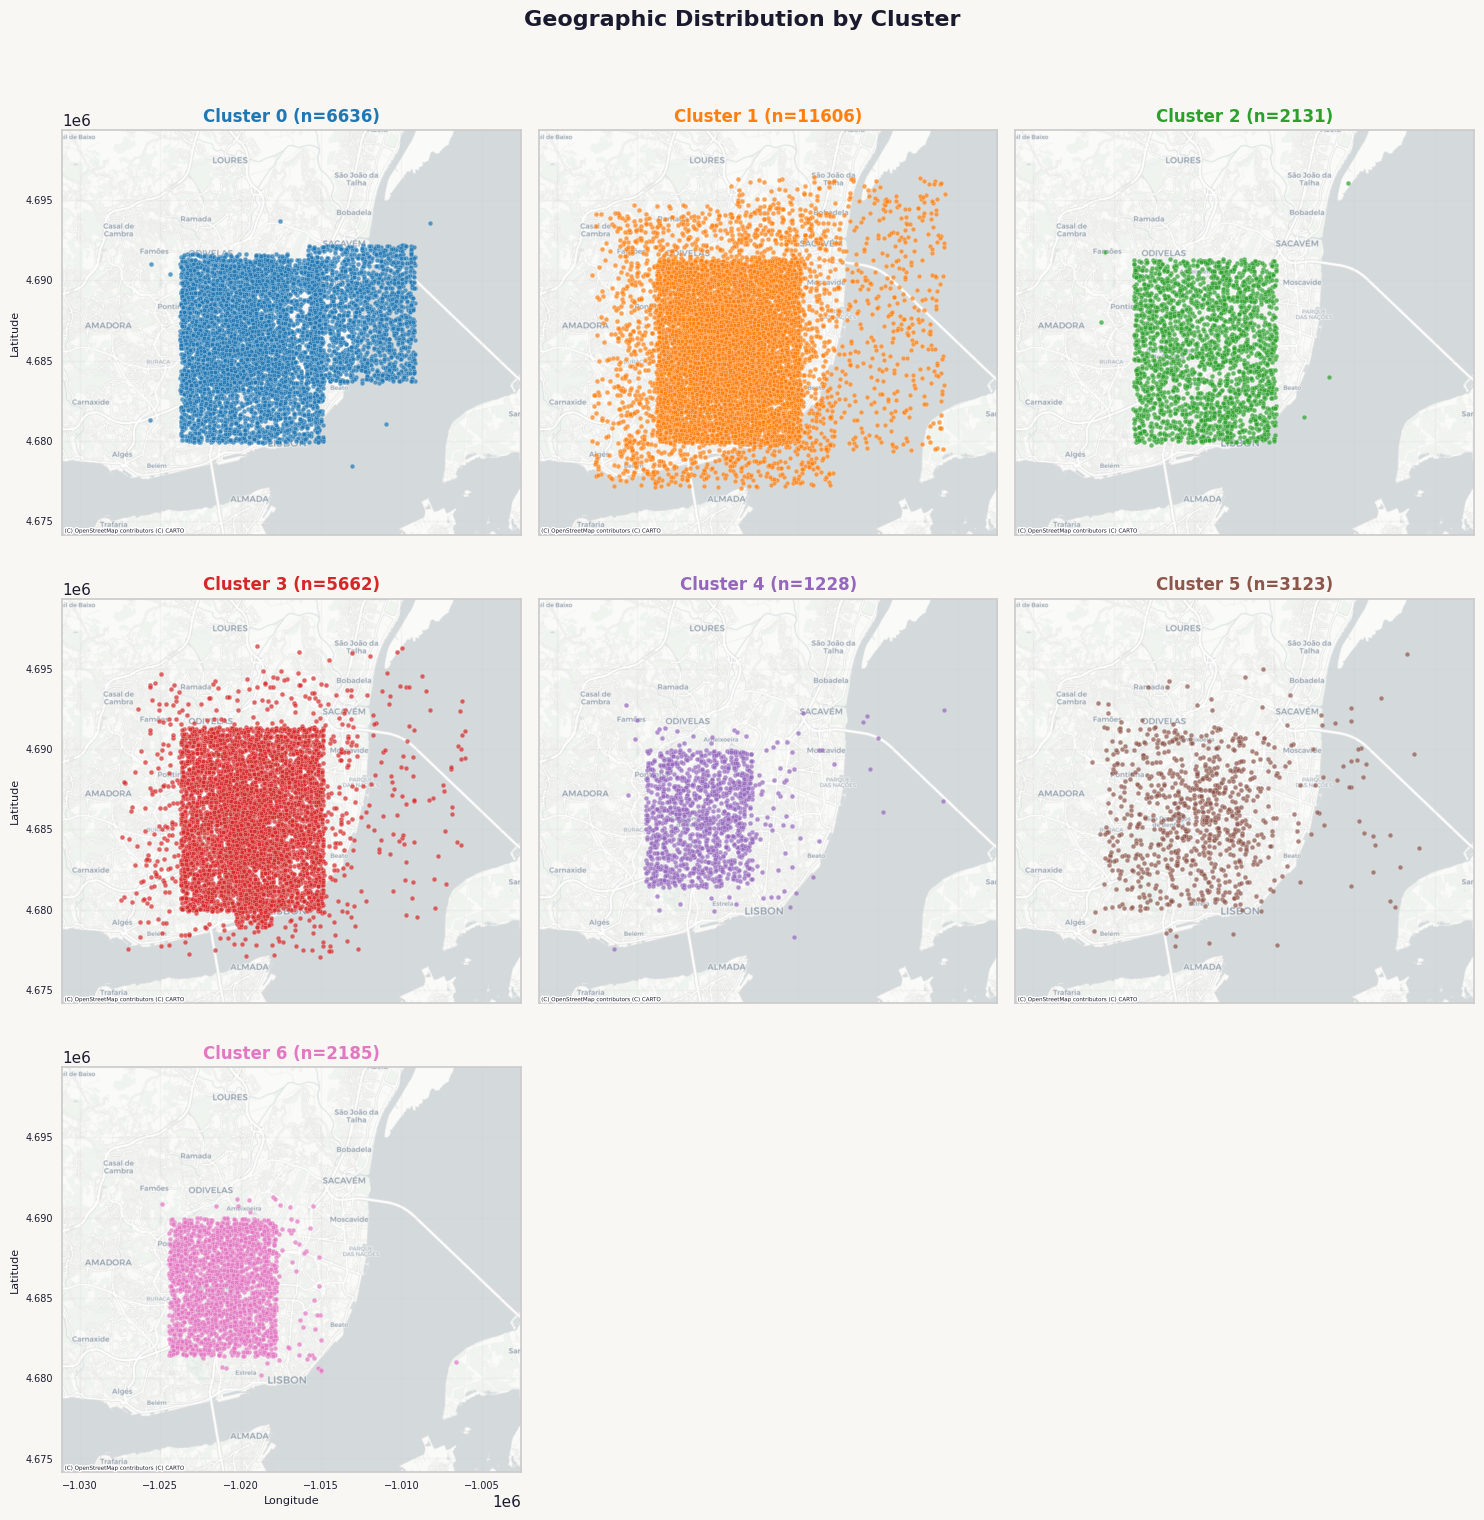

In [ ]:
plot_cluster_geography(clean_rb, ward_labels_rb)

The clusters don't show meaningful relations from the geographical plots, so we have no further use for the displayed maps.

# **4. Exporting data**

In [ ]:
clean_data

,customer_id,customer_name,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood,dietary_preference,final_cluster_nr,final_cluster_label
0,3,Bsc. Crystal Kitchens,female,1.0,1.0,1.0,3.0,11731.0,4553.0,12.0,...,0.017375,0.009521,0.001506,0.011458,0.029693,0.013771,0.020656,omnivore,1,Loyal core spenders
1,4,Bsc. Glenda Bauman,female,1.0,0.0,0.0,2.0,13694.0,963.0,12.0,...,0.026343,0.004695,0.002125,0.000741,0.092918,0.016458,0.032867,omnivore,0,Vegans
2,5,Msc. Antonio Campbell,male,0.0,0.0,0.0,2.0,12407.0,0.0,11.0,...,0.006496,0.007589,0.081356,0.017557,0.032607,0.006496,0.014277,omnivore,1,Loyal core spenders
3,7,John Kelling,male,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,...,0.050629,0.075776,0.065008,0.072432,0.032437,0.110754,0.012306,omnivore,4,Gamers
4,8,Arthur Dematteo,male,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,...,0.022948,0.027833,0.041400,0.039346,0.011513,0.048765,0.017095,omnivore,6,Tech enthusiasts
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32566,39996,Joshua Howard,male,0.0,0.0,2.0,1.0,475.0,13488.0,12.0,...,0.028765,0.049900,0.051205,0.057932,0.003112,0.080221,0.018373,omnivore,6,Tech enthusiasts
32567,39997,Anthony Hines,male,1.0,0.0,1.0,1.0,8430.0,14408.0,21.0,...,0.016836,0.048001,0.044817,0.020393,0.007453,0.071308,0.007690,omnivore,6,Tech enthusiasts
32568,39998,Edna Hasselman,female,1.0,1.0,0.0,4.0,8029.0,1480.0,14.0,...,0.035053,0.008302,0.021784,0.000000,0.121975,0.006315,0.018307,omnivore,0,Vegans
32569,39999,George Kramer,male,1.0,1.0,1.0,6.0,8364.0,3114.0,11.0,...,0.021979,0.047947,0.000000,0.008197,0.029740,0.000000,0.016321,omnivore,1,Loyal core spenders


In [ ]:
#clean_data.to_csv('data/ci_clustered.csv', index=False)